[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework11.ipynb)

# Exercise
In this exercise we will explore, how well the phenomena of meaningful vector embedding, using pretrained embedding GloVe.

Firstly, we create 10 classes, each of them contains 5 pairs of words, which are semantically related. Some ideas for the categories were proposed in the instruction, some of them were invented by me.

At the end we will see which class will "behave the best". Here are the 10 classes:
- class 1: Gender
- class 2: Present / past form of a verb
- class 3: Country / capital
- class 4: Adjective in comparative / superlative form
- class 5: Musician / genre of music they make
- class 6: Artist / piece of art
- class 7: Singular / plural noun
- class 8: An object / part of the object
- class 9: Opposites
- class 10: Profession / tool

In [137]:
class_1 = [["king", "queen"], ["man", "woman"], ["doctor", "nurse"], ["prince", "princess"], ["actor", "actress"]]
class_2 = [["bring", "brought"], ["get", "got"], ["like", "liked"], ["apply", "applied"], ["make", "made"]]
class_3 = [["poland", "warsaw"], ["france", "paris"], ["germany", "berlin"], ["greece", "athens"], ["spain", "madrid"]]
class_4 = [["better", "best"], ["greater", "greatest"], ["funnier", "funniest"], ["sadder", "saddest"], ["kinder", "kindest"]]
class_5 = [["beethoven", "classical"], ["eminem", "rap"], ["metallica", "rock"], ["rihanna", "pop"], ["coltrane", "jazz"]]
class_6 = [["writer", "book"], ["sculptor", "sculpture"], ["painter", "paint"], ["photographer", "photo"], ["poet", "poem"]]
class_7 = [["watch", "watches"], ["cup", "cups"], ["bag", "bags"], ["fridge", "fridges"], ["lamp", "lamps"]]
class_8 = [["car", "wheel"], ["hand", "finger"], ["house", "room"], ["tree", "branch"], ["image", "pixel"]]
class_9 = [["hot", "cold"], ["short", "tall"], ["bright", "dark"], ["ugly", "beautiful"], ["skinny", "fat"]]
class_10 = [["blacksmith", "hammer"], ["teacher", "chalk"], ["hairdresser", "scissors"], ["chef", "knife"], ["logger", "axe"]]

categories_of_classes = {
    1: 'Gender',
    2: 'Present / past form of a verb',
    3: 'Country / capital',
    4: 'Adjective in comparative / superlative form',
    5: 'Musician / genre of music they make',
    6: 'Artist / piece of art',
    7: 'Singular / plural noun',
    8: 'An object / part of the object',
    9: 'Opposites',
    10: 'Profession / tool'
}

Then, we import the Glove embeddings and find the embeddings for our words.

In [124]:
!pip install -q gensim

In [125]:
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-200")

In [138]:
import numpy as np
number_of_classes = 10
classes = [class_1, class_2, class_3, class_4, class_5, class_6, class_7, class_8, class_9, class_10]
all_words = [word for my_class in classes for pair in my_class for word in pair]
word_embed = np.array([model[word] for word in all_words])

In [127]:
!pip install adjustText

Now, we perform PCA, to be able to plot how the vectors representing our words are scattered over the 2d plane.

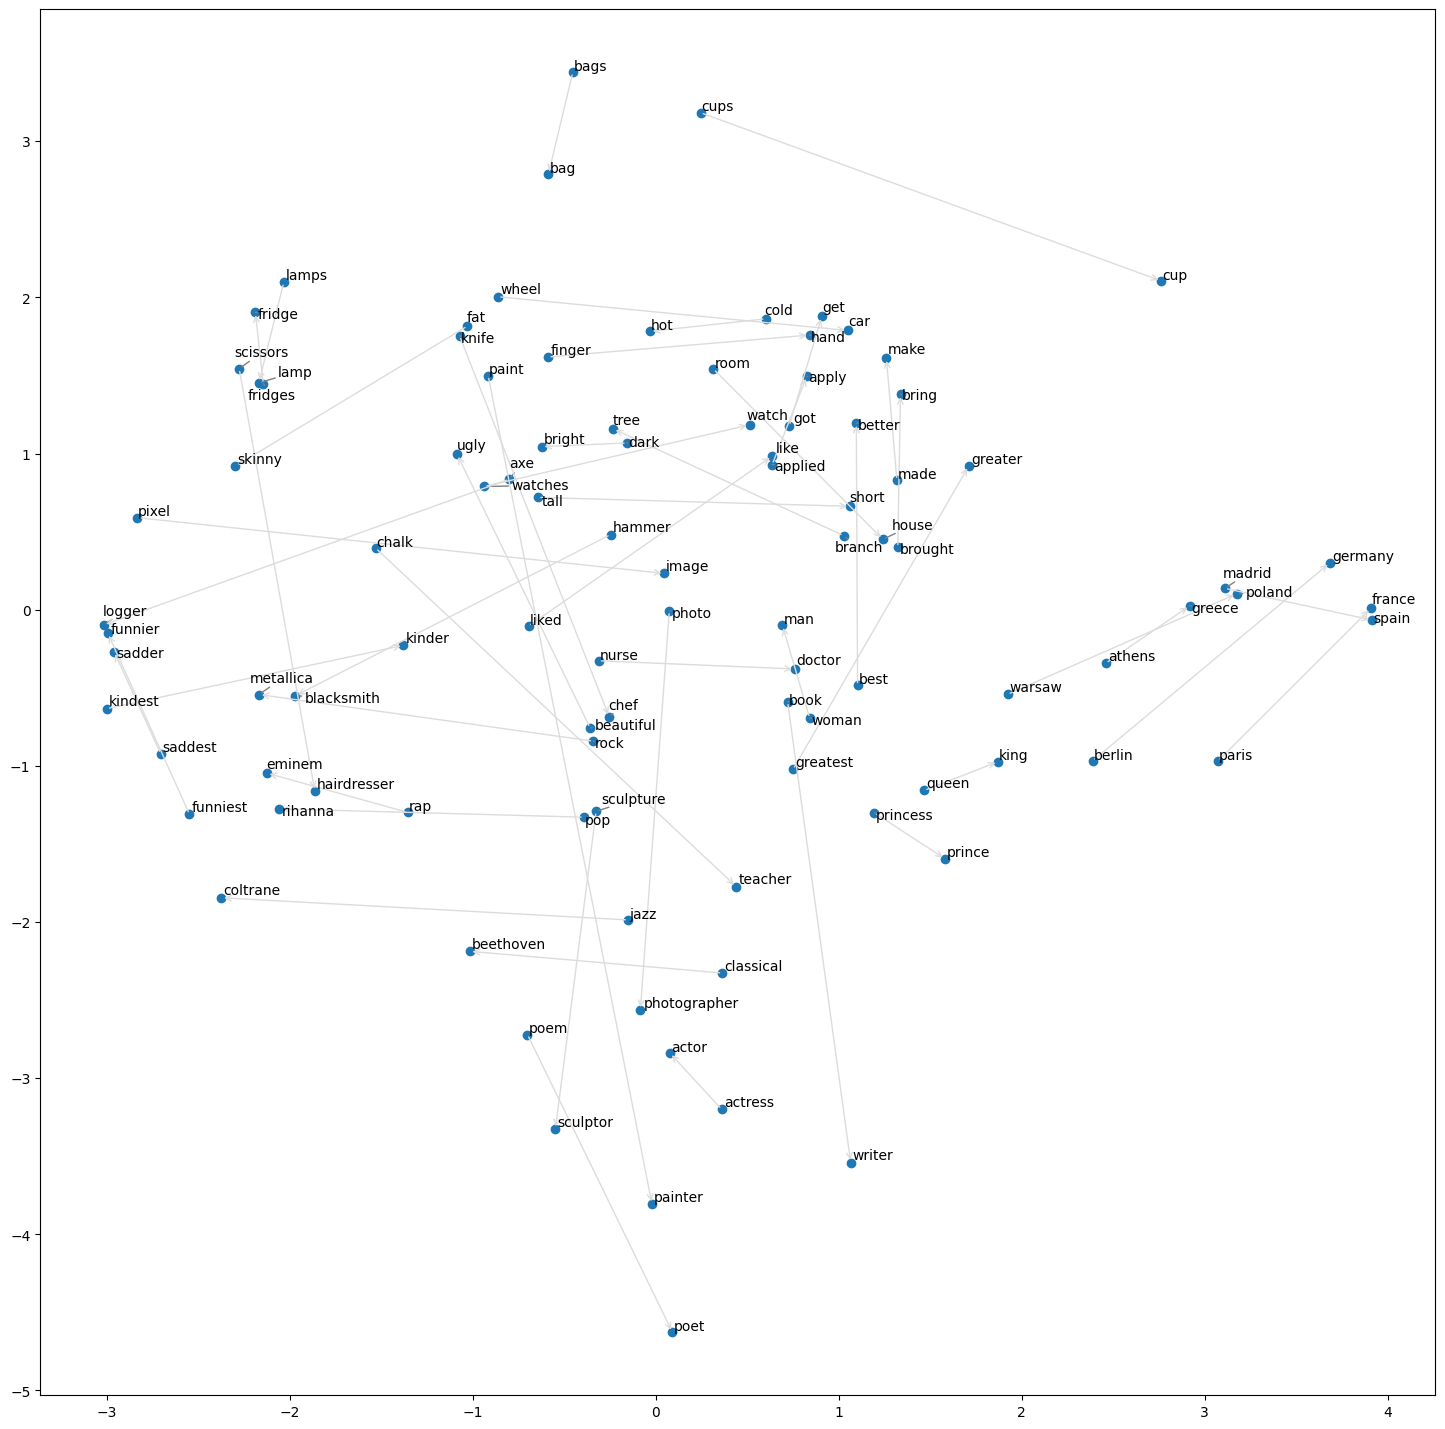

In [139]:
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from adjustText import adjust_text

# Perform PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(word_embed)
plt.figure(figsize= (18, 18))
plt.scatter(pca_results[:, 0], pca_results[:, 1])

# Create arrows
for k in range(50):
    plt.annotate("",
                 xy=(pca_results[2*k,0], pca_results[2*k,1]),
                 xytext=(pca_results[2*k + 1,0], pca_results[2*k + 1,1]),
                 arrowprops=dict(arrowstyle="->",
                  color="#DCDCDC"))

# Create labels
texts = []
for i, word in enumerate(all_words):
  texts.append(plt.annotate(word, (pca_results[i, 0], pca_results[i, 1])))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))
plt.show()

Now we want to see how the plot looks like for each class independently.

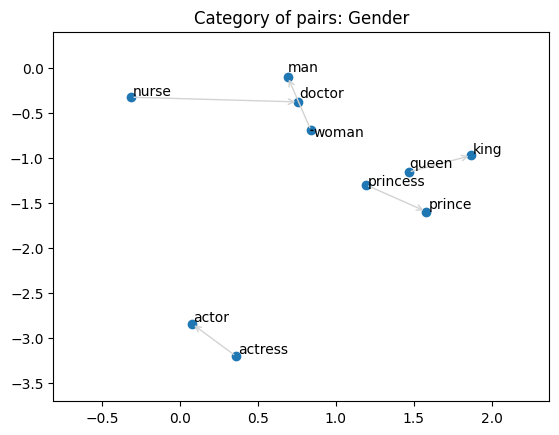

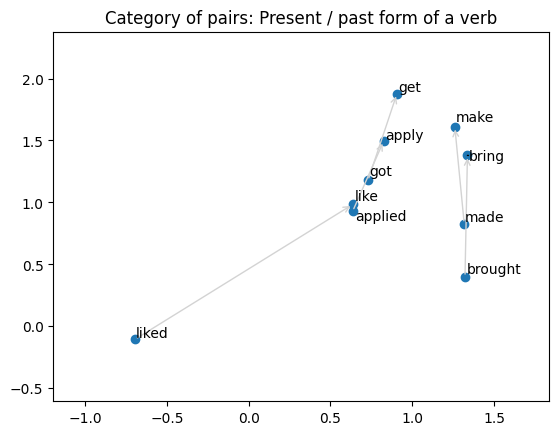

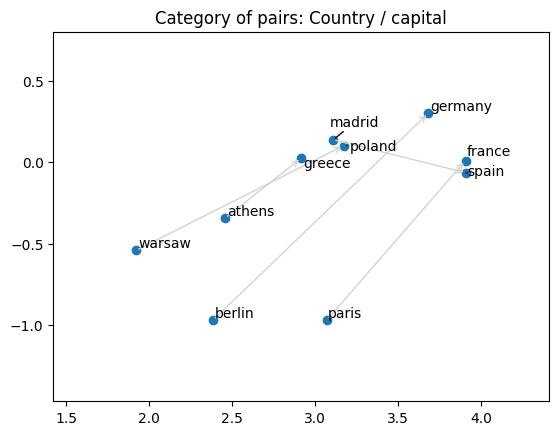

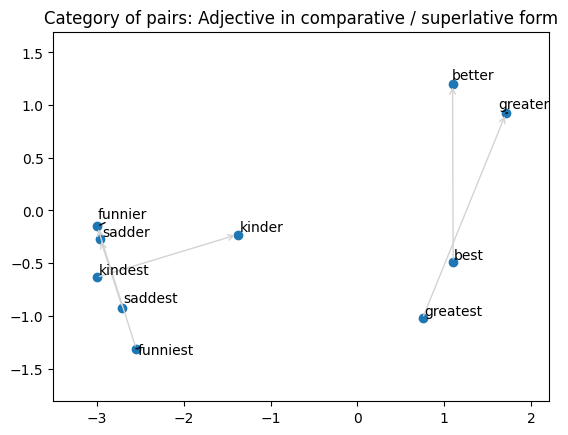

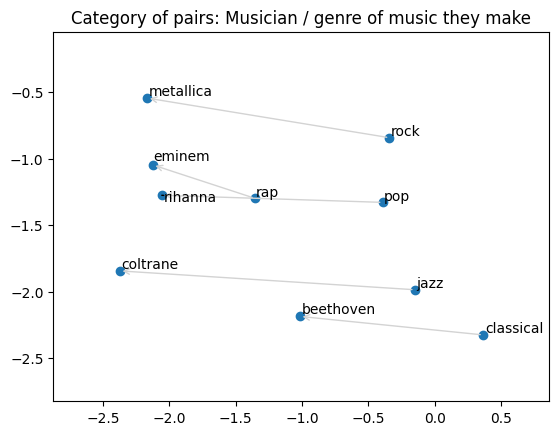

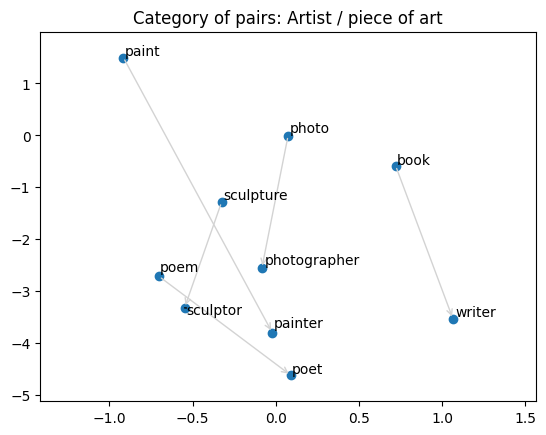

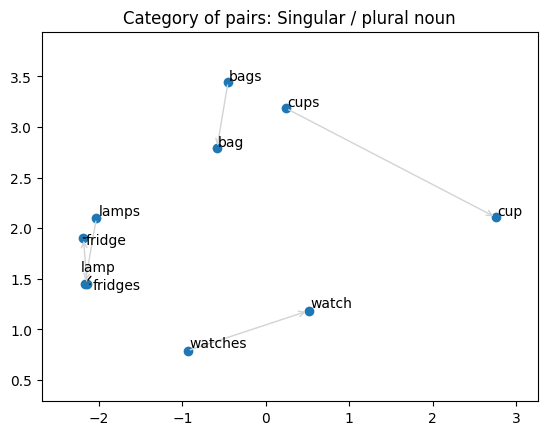

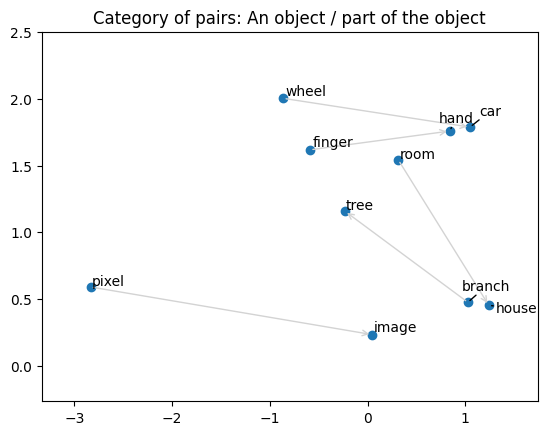

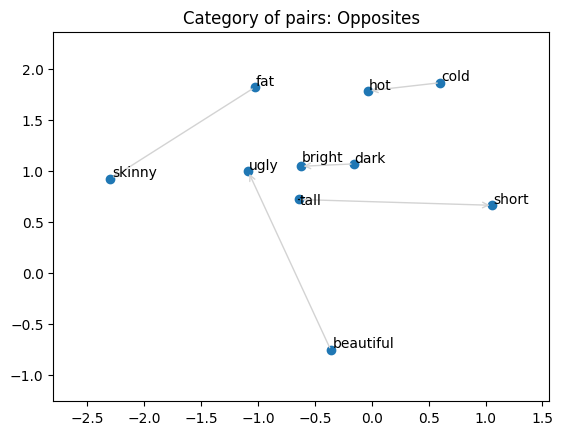

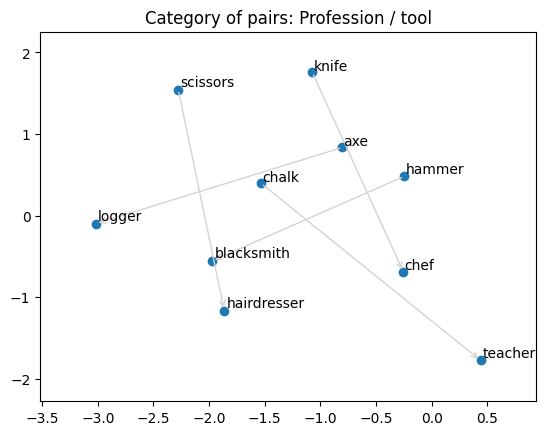

In [140]:
epsilon = 0.5
for i in range(number_of_classes):
  plt.scatter(pca_results[i*10:(i+1)*10, 0], pca_results[i*10:(i+1)*10, 1])
  x_min, x_max = pca_results[i*10:(i+1)*10,0].min(), pca_results[i*10:(i+1)*10,0].max()
  y_min, y_max = pca_results[i*10:(i+1)*10,1].min(), pca_results[i*10:(i+1)*10,1].max()

  plt.xlim(x_min - epsilon, x_max +  epsilon)
  plt.ylim(y_min- epsilon, y_max + epsilon)
  plt.title(f"Category of pairs: {categories_of_classes[i + 1]}")
  curr_class = classes[i]
  curr_class = [word for pair in curr_class for word in pair]
  texts = []
  for k in range(5):
    plt.annotate("",
                 xy=(pca_results[i*10 + 2*k,0], pca_results[i*10 + 2*k,1]),
                 xytext=(pca_results[i*10 + 2*k + 1,0], pca_results[i*10 + 2*k + 1,1]),
                 arrowprops=dict(arrowstyle="->",
                  color="#D3D3D3"))
  for j, word in enumerate(curr_class):
    texts.append(plt.annotate(word, (pca_results[i*10+j, 0], pca_results[i*10+j, 1])))
  adjust_text(texts, arrowprops=dict(arrowstyle='-'))
  plt.show()



We perform PCA on each class separately to see if there are any diffrences in the locations of the vectors representing words.

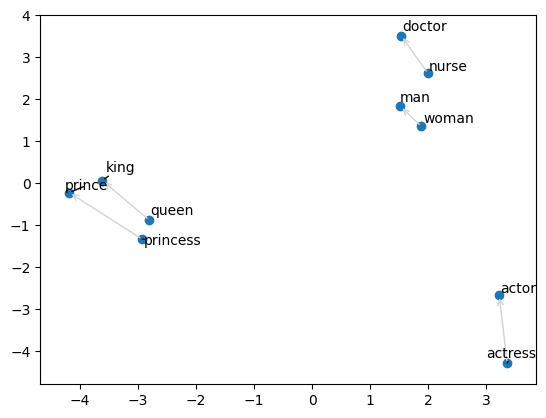

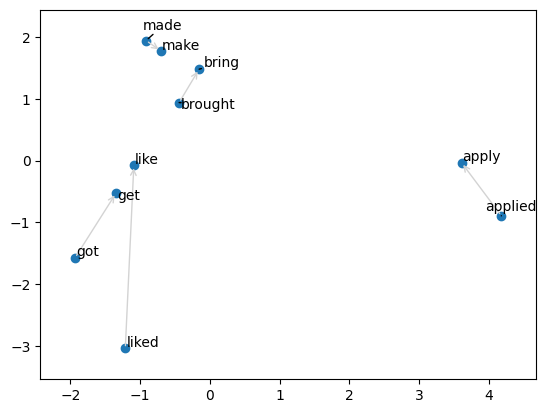

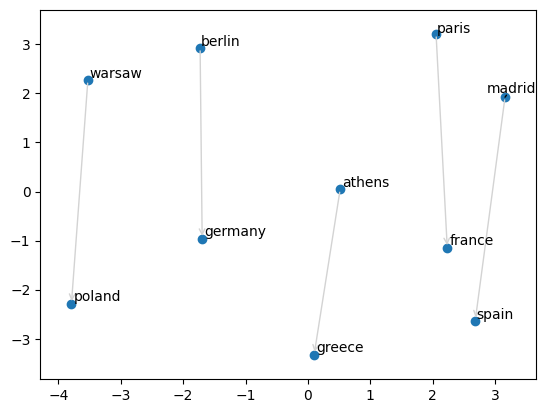

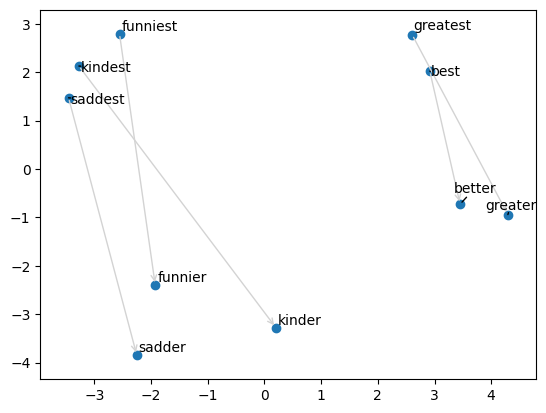

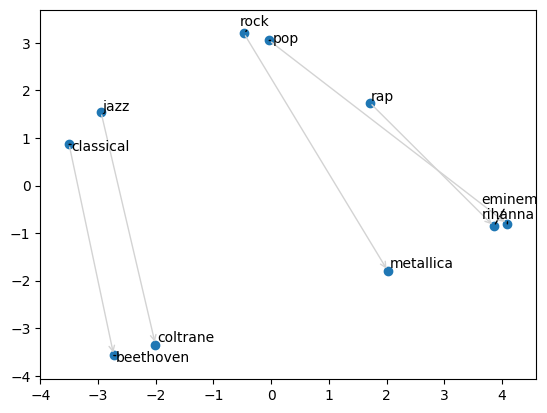

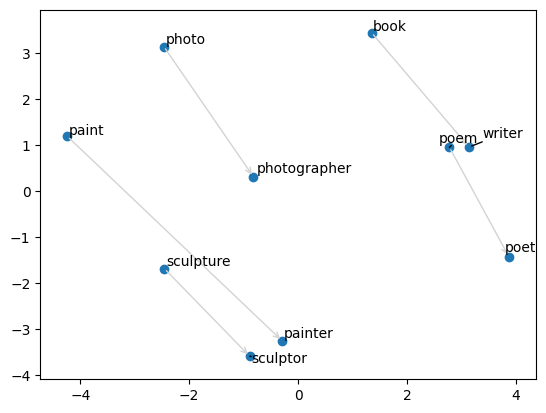

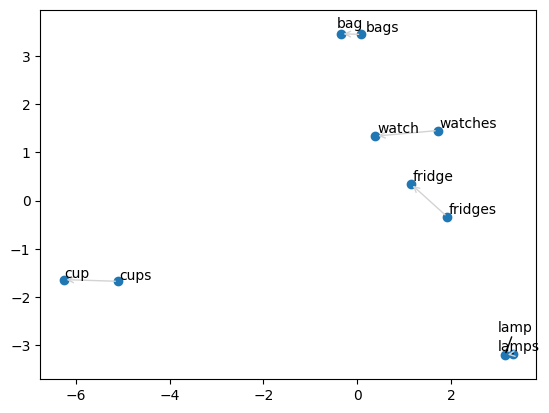

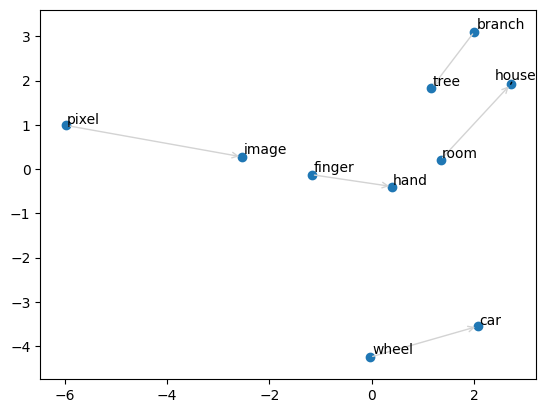

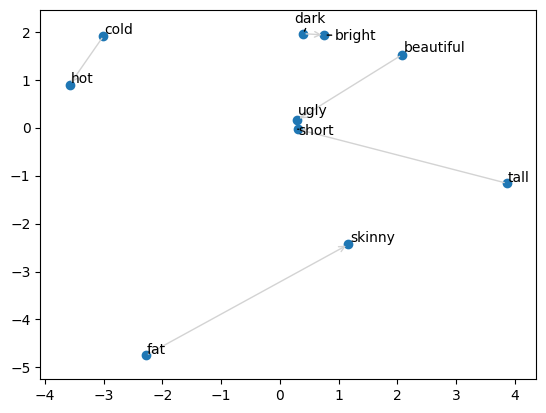

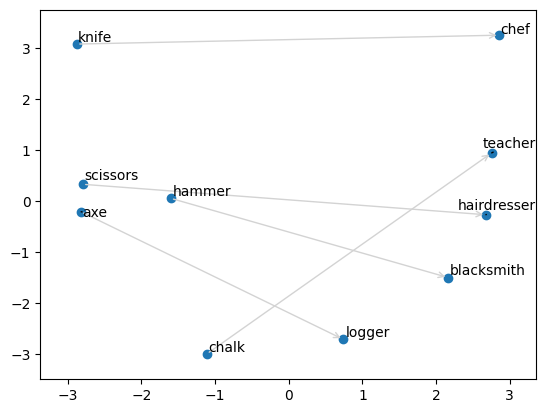

In [141]:
epsilon = 0.5
for i in range(len(classes)):
  pca = PCA(n_components=2)
  pca_results = pca.fit_transform(word_embed[i*number_of_classes:(i+1)*number_of_classes])

  plt.scatter(pca_results[:, 0], pca_results[:, 1])
  x_min, x_max = pca_results[:,0].min(), pca_results[:,0].max()
  y_min, y_max = pca_results[:,1].min(), pca_results[:,1].max()
  plt.xlim(x_min - epsilon, x_max +  epsilon)
  plt.ylim(y_min - epsilon, y_max + epsilon)
  curr_class = classes[i]
  curr_class = [word for pair in curr_class for word in pair]
  texts = []

  for k in range(5):
    plt.annotate("",
                xy=(pca_results[2*k,0], pca_results[2*k,1]),
                xytext=(pca_results[2*k + 1,0], pca_results[2*k + 1,1]),
                arrowprops=dict(arrowstyle="->",
                color="#D3D3D3"))

  for j, word in enumerate(curr_class):
    texts.append(plt.annotate(word, (pca_results[j, 0], pca_results[j, 1])))
  adjust_text(texts, arrowprops=dict(arrowstyle='-'))
  plt.show()

In [148]:
from math import dist
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

how_many_words = 10
for i in range(number_of_classes):
  curr_class = classes[i]
  sol = word_embed[i*10+0] - word_embed[i*10+2] + word_embed[i*10 + 3]

  # We calculate the closest words using classic Euclidean distance.
  euclid_dist = np.array([dist(sol, word_embed[i*10+j]) for j in range(how_many_words)])
  euclid_indexes = np.argsort(euclid_dist)[:5]
  euclid_dist = euclid_dist[euclid_indexes]


  # We calucate the closest words using dot product and cosine metric.
  cosine_dist = np.array([cosine_similarity(sol.reshape(1, -1), word_embed[i*10+j].reshape(1, -1))[0][0]
                           for j in range(how_many_words)])
  cosine_indexes = np.argsort(cosine_dist)[::-1][:5]
  cosine_dist = cosine_dist[cosine_indexes]

  print(f"The closest word to the 'equation' {all_words[i*10+0]} - {all_words[i*10+2]} + {all_words[i*10+3]} =")
  data = {
      "Euclid": [all_words[i*10+j] for j in euclid_indexes],
      "Euclide_dist": euclid_dist,
      "Cosine": [all_words[i*10+j] for j in cosine_indexes],
      "Cosine_value": cosine_dist
  }
  df = pd.DataFrame(data)
  df.index = range(1, len(df) + 1)
  display(df)
  print("\n")


The closest word to the 'equation' king - man + woman =


,Euclid,Euclide_dist,Cosine,Cosine_value
1,king,4.419310,king,0.820907
2,queen,5.532314,queen,0.711917
3,princess,6.432821,princess,0.612122
4,prince,6.618345,prince,0.596004
5,woman,7.098897,woman,0.508291




The closest word to the 'equation' bring - get + got =


,Euclid,Euclide_dist,Cosine,Cosine_value
1,bring,2.948112,bring,0.819177
2,brought,3.106723,brought,0.776888
3,got,4.519714,got,0.621440
4,made,4.986406,made,0.518715
5,make,5.115707,make,0.517204




The closest word to the 'equation' poland - france + paris =


...

,Euclid,Euclide_dist,Cosine,Cosine_value
1,car,4.832669,car,0.767022
2,finger,6.821987,finger,0.488127
3,wheel,7.100934,wheel,0.474510
4,hand,8.341727,room,0.193470
5,room,8.507150,tree,0.188909




The closest word to the 'equation' hot - short + tall =


,Euclid,Euclide_dist,Cosine,Cosine_value
1,hot,7.082798,hot,0.650953
2,tall,7.237925,tall,0.638521
3,bright,8.898458,bright,0.386145
4,beautiful,9.042738,beautiful,0.373315
5,cold,9.220765,cold,0.358547




The closest word to the 'equation' blacksmith - teacher + chalk =


,Euclid,Euclide_dist,Cosine,Cosine_value
1,chalk,7.477860,chalk,0.580997
2,blacksmith,7.956277,blacksmith,0.506695
3,logger,9.464880,scissors,0.220309
4,scissors,9.674060,logger,0.194910
5,hammer,10.005377,axe,0.149121


# Conclusions
* From the first big plot, we see that semantic meanings of the words were captured by PCA -- we can see the cluster of capitals/countries on the left, cluster of adjectives on the left and cluster of profession down.
* Local PCA also does the good job, we can see that in more than half plots the arrows are pointing in similar directions. This means that similarities in the semantics were captured, especially in the categories: "Countries/capitals", "Gender", "Musicians/genre" and "Artist/piece of art"
* Some classes behaved better than others. The best categories were "Countries/capitals" and "Comparatives/suprelatives". That can be happening, because there is straight corrrelations between the two terms and they often appear in the sentences simultaneously.
* Unfortunately, some relations were not captured. The biggest example is "Opposites", where the arrows are pointing in random directions and the correct answer to our "equation" is on the 5th place.
* In the category Single/Plural words in pairs were very closed to each other, but the arrows were again pointing in random directions, so the equation does not give satisfying results.
* Both metrics (Euclidean and cosine) gave similar results. That means that data were well-normalized and all diffrences come from the angles.
